# 7. The genes that change along a lineage

Tutorial 06 put the cells of each lineage in order. This asks what that order is
*made of*: which genes change along it, and in what order they change.

It is the question Monocle and tradeSeq exist to answer, and it is not the
question tutorial 05 answers. `find_marker_genes` asks which genes one trained
model used to decide what a cell is, across the 5,000 genes that model reads.
This asks which genes move along the order, across every gene you sequenced,
from measured expression, with the model not involved at all.

**Two things it is not.** It is not a comparison between cell types — nothing
here is grouped by label. And it is not a statement about time: the order is a
rank, so a gene peaking at 0.5 peaks where half that lineage's cells have gone
before it, not half way through development.

## Getting there

The same developing retina as tutorials 03, 04 and 06, and the same three steps.
If you have run tutorial 06 in this directory the download is already done.

> Zuo Z, Cheng X, Ferdous S, *et al.* "Single cell dual-omic atlas of the human
> developing retina." *Nat Commun* **15**, 6792 (2024).
> doi:[10.1038/s41467-024-50853-5](https://doi.org/10.1038/s41467-024-50853-5)

In [1]:
import pathlib
import shutil
import urllib.request

URL = ("https://datasets.cellxgene.cziscience.com/"
       "883270e9-41e6-4c2c-b352-b15c292d2a34.h5ad")
SOURCE = pathlib.Path("retina_fetal.h5ad")

if not SOURCE.exists():
    with urllib.request.urlopen(URL) as response, open(SOURCE, "wb") as handle:
        shutil.copyfileobj(response, handle)

`.raw.to_adata()` matters here more than anywhere else in these tutorials. This
step scales each cell by its library size and takes a logarithm, so it needs raw
counts and refuses anything already normalised rather than transforming it twice.

In [2]:
import anndata as ad
import numpy as np

full = ad.read_h5ad(SOURCE, backed="r")
rng = np.random.default_rng(0)
chosen = np.sort(rng.choice(full.n_obs, 25_000, replace=False))
adata = full[chosen].to_memory()
full.file.close()

adata = adata.raw.to_adata()
print("largest value:", adata.X.max(), "— whole numbers:",
      float(adata.X.max()) == int(adata.X.max()))

largest value: 3395.0 — whole numbers: True


Predict, build the trajectory, order the cells. Tutorial 06 explains each of
these and why the `lineages` list below is needed; the short version is that the
ontology has no term narrower than `central nervous system neuron` above both
amacrine and horizontal cells, so without the list those two families are ranked
against each other as though they were one path.

In [3]:
import hector

predictor = hector.HECTOR("human")
predictions = predictor.predict(adata, label_format="name")
predictor.write_predictions(adata, predictions)

hector.create_trajectory_analysis(
    predictor=predictor, adata=adata, output_file="07_tree.pdf",
    title="Developing human retina", label_format="name", min_cells_number=20)

hector.create_pseudotime_analysis(
    predictor=predictor, adata=adata,
    lineages=["amacrine cell", "retina horizontal cell",
              "retinal rod cell + retinal cone cell", "retinal bipolar neuron"])

<environment>/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  ☑️  MLX encoder loaded
  ☑️  MLX CellTypeEmbedder loaded
  ☑️  MLX HPLHead loaded


  📂 Loaded Memory Bank: 100,000 anchor cells
 🎉 Model loaded successfully! 🥳
   Prediction hardware: GPU (Apple M1 Max, MLX)
   Supported cell types: 1407
  [INFO] Making predictions on 25000 cells...
  Settings: top_k=1, use_grit=True, zero_shot=True
  Step 0: Checking gene IDs...
  Step 1: Gene Matching and Reordering ...


  Gene matching: 4983/5000 (99.7% of reference genes found)
  Step 2: Processing expression data...


  MLX adaptive batch size: 23999 (budget 17.0 GB, floor 5.7 GB)


...

[INFO] Layout pipeline: Using PURE ontology DAG
[INFO] Visual pipeline: Building visual edges


[HECTOR] auto-detected stable_source_zone=0.1339, stable_target_zone=0.0229  (mode=auto)


  > Tagged 11976 Transitioning Typical, 12967 Stable Typical, 0 Clustered Atypical, and 0 Unclustered Atypical cells.
  Cells: 24943 | Nodes: 41 | Edges: 50 (inferred paths: 0)
Plot generating......


✅ Saved: 07_tree.pdf

[Pseudotime] 39 cell types occupied.



  8 lineages, each ranked 0-1 on its own:
    precursor cell                                           1 cell types     8,210 cells
    camera-type eye photoreceptor cell                       3 cell types     5,057 cells
    retinal ganglion cell                                    6 cell types     4,685 cells
    amacrine cell                                            4 cell types     2,855 cells
    retinal bipolar neuron                                  13 cell types     2,455 cells
    retina horizontal cell                                   2 cell types     1,210 cells
    glial cell                                               2 cell types       466 cells
    central nervous system neuron                            1 cell types         4 cells

  glutamatergic neuron: 1 cells (0.0%), no pseudotime. It sits under none of
  the 8 lineage names listed above, so there is no lineage to rank it within;
  hector_lineage keeps its own name.

  57 cells (0.2%) were never placed on an e

## One call

It prints a line per lineage while it runs, because on a full atlas this takes
minutes. On this 25,000-cell slice it takes about one.

In [4]:
trends = hector.create_gene_trend_analysis(adata)
trends.head()


[Gene trends] counts from adata.X, 8 lineages, please wait...


  precursor cell                                   8,210 cells     4,667 of 20,182 genes change


  camera-type eye photoreceptor cell               5,057 cells     3,656 of 16,667 genes change


  retinal ganglion cell                            4,685 cells     8,018 of 20,021 genes change


  amacrine cell                                    2,855 cells     3,142 of 16,254 genes change


  retinal bipolar neuron                           2,455 cells     4,184 of 14,906 genes change


  retina horizontal cell                           1,210 cells       930 of 12,807 genes change


  glial cell                                         466 cells       337 of 10,162 genes change


  central nervous system neuron                        4 cells   no gene reaches 25 cells

  24,934 rows. Sorted by lineage then by where the gene peaks, so reading a
  lineage's rows top to bottom is the gene ordering.


,lineage,order_in_lineage,gene_id,symbol,n_cells,strength,p_value,q_value,bendiness,peak_location,peak_height,trough_location,trough_depth,starts_at,ends_at,share_of_pseudotime_above_average,cell_type_at_peak
0,amacrine cell,1,ENSG00000074800,ENO1,1157,3.158937,0.000015,0.000171,4.0,0.00035,2.849728,1.00000,-2.738689,2.849728,-2.738689,0.4650,GABAergic amacrine cell
1,amacrine cell,2,ENSG00000204624,DISP3,774,2.497959,0.000215,0.001900,12.0,0.00035,2.257283,0.70687,-2.197981,2.257283,0.531973,0.5725,GABAergic amacrine cell
2,amacrine cell,3,ENSG00000169991,IFFO2,140,2.162520,0.002094,0.013855,4.0,0.00035,3.120063,1.00000,-2.702405,3.120063,-2.702405,0.4450,GABAergic amacrine cell
3,amacrine cell,4,ENSG00000125944,HNRNPR,1832,2.552894,0.000077,0.000750,4.0,0.00035,2.174552,1.00000,-1.402248,2.174552,-1.402248,0.4500,GABAergic amacrine cell
4,amacrine cell,5,ENSG00000142661,MYOM3,26,2.432981,0.000181,0.001631,4.0,0.00035,2.894202,1.00000,-1.692153,2.894202,-1.692153,0.3800,GABAergic amacrine cell


Nothing was written onto `adata`. The table is the result and saving it is
yours — `trends.to_csv("07_gene_trends.csv")` opens in Excel.

### How it decides

**Whether a gene changes** comes from a walk. Line the lineage's cells up in
order and keep a running total of how far each cell sits above or below that
gene's own average. Because the amounts above and below an average cancel, the
total always ends where it started, so the ending says nothing and the journey
says everything: it travels far only when the cells holding a lot of the gene
are **bunched together** somewhere along the order, which is what "this gene
switches on at a particular stage" means. What is measured is the total's
highest point less its lowest.

Nothing about that is binned, smoothed or fitted, so nothing about it is set by
anyone. How big a journey counts as big comes from shuffling the cell order
twenty times and seeing how far chance travels for a gene of that sparsity.

**Where a gene peaks** comes from a curve fitted through the cells, because the
walk cannot answer it — every position a walk can offer is an average over the
axis, and an average is pulled towards the middle. How bendy that curve may be
is chosen for each gene separately, by hiding a fifth of the cells, fitting on
the rest at several levels, and keeping the level that best predicts the cells
it never saw. Nobody types that number either.

### The ruler, held fixed

Tutorial 06 explained that the ontology states the order wherever it can and a
count of how many genes each cell expresses settles the pairs it says nothing
about. That count is therefore part of the ruler this order was built with — so
a gene that merely tracks it would look like a gene that changes along the
lineage.

Both stages above are run on what a straight line against that count leaves of
each gene. It costs about 25% of the genes here — 24,934 pass against 33,357
unadjusted. HES1 is one of them: it passes in the precursor and glial lineages
before the adjustment and not after, because a proliferating cell expresses
more genes than a mature one, which is exactly the confusion the adjustment
exists to prevent. Pass `hold_detected_genes_fixed=False` to see the unadjusted
answer.

## What is in the table

One row per gene per lineage, sorted by lineage and then by where the gene
peaks — so reading a lineage's rows top to bottom is the gene ordering itself.

In [5]:
photoreceptor = trends[trends["lineage"] == "camera-type eye photoreceptor cell"]
photoreceptor[photoreceptor["symbol"].isin(
    ["MKI67", "SOX2", "THRB", "GNAT2", "ARR3", "NRL", "RCVRN", "GNAT1", "RHO",
     "SAG"])][["symbol", "peak_location", "peak_height", "starts_at", "ends_at",
               "share_of_pseudotime_above_average", "cell_type_at_peak"]].round(2)

,symbol,peak_location,peak_height,starts_at,ends_at,share_of_pseudotime_above_average,cell_type_at_peak
3367,SOX2,0.00,1.68,1.68,-1.53,0.50,retinal cone cell
4295,THRB,0.02,4.86,-0.81,2.08,0.30,S cone cell
4476,MKI67,0.03,3.37,0.98,-2.17,0.48,S cone cell
4874,GNAT2,0.10,2.95,0.16,1.56,0.48,S cone cell
5662,RCVRN,0.68,1.06,-1.58,0.11,0.61,retinal rod cell
5670,NRL,0.69,0.79,-4.20,-1.24,0.67,retinal rod cell
6173,GNAT1,0.98,1.94,-0.27,1.30,0.51,retinal rod cell
6287,SAG,1.00,2.62,-1.29,2.62,0.45,retinal rod cell
6310,RHO,1.00,1.84,-1.02,1.84,0.56,retinal rod cell


The columns worth knowing, since several are easy to misread.

* `peak_location` is **where**, on the same 0-to-1 pseudotime. `peak_height` is
  **how much** — how far above the gene's own average the curve gets there, in
  standard deviations of that gene's own curve. Two genes can peak at the same
  moment and be nothing alike.
* `starts_at` and `ends_at` are the curve at pseudotime 0 and 1, on that same
  scale. Strongly positive at the end means the gene switches on. **Near zero
  does not mean the gene does nothing** — it means the gene ends where it
  started, which is what a brief flare does: a cone gene can reach four standard
  deviations above its own average partway along and still end where it began.
* `share_of_pseudotime_above_average` is the only column that separates a brief
  flare from a gene that is simply on for most of the lineage.
* `strength` is a signal-to-noise figure, **not an effect size**. It ranks
  well-measured genes first. In the photoreceptor lineage RHO ranks 3,436th of
  the 3,656 genes that pass, because it is detected in 66 cells: this is fetal
  retina and rods are only just switching it on. Use `strength` to decide what
  to draw, never to decide which genes are real.
* `cell_type_at_peak` names one point on the gene's curve and nothing more. It
  does not say the gene is specific to that cell type, or even that it is
  expressed in it — and where one cell type fills a whole lineage, every gene
  carries its name and the column says nothing.

## Asking it things

Every filter below is one comparison, and none of them needs to know how the
method works.

In [6]:
switching_on = photoreceptor[(photoreceptor["ends_at"] > 2)
                             & (photoreceptor["peak_location"] > 0.8)]
brief = photoreceptor[photoreceptor["share_of_pseudotime_above_average"] < 0.25]
among_rods = photoreceptor[photoreceptor["cell_type_at_peak"] == "retinal rod cell"]

for name, found in [("switch on and stay on", switching_on),
                    ("concentrated in a short stretch", brief),
                    ("peak among the rod cells", among_rods)]:
    strongest = found.nlargest(6, "strength")["symbol"].tolist()
    print(f"{len(found):>5,} genes {name}: {', '.join(strongest)}")

  420 genes switch on and stay on: TLL1, DISC1, RIMS2, PPP2R2B, GPR160, ALK
  137 genes concentrated in a short stretch: ONECUT1, KCNQ5, CNTNAP5, DLL3, PHACTR2, TLE1
1,668 genes peak among the rod cells: NTM, CADM1, PTPN13, USH2A, PTPRZ1, TLL1


## Drawing it

The table says which genes, in what order, and how smooth each curve is. The
object supplies the cells. The curve itself is refitted here rather than stored,
which costs about two seconds for a whole figure and keeps the table a table.

In [7]:
MARKERS = {
    "camera-type eye photoreceptor cell":
        ["MKI67", "SOX2", "CRX", "THRB", "GNAT2", "ARR3", "NRL", "NR2E3",
         "RCVRN", "GNAT1", "RHO", "SAG"],
    "retinal ganglion cell":
        ["ATOH7", "POU4F2", "ISL1", "CNTN2", "GAP43", "SNCG", "RBPMS", "NEFL"],
    "amacrine cell":
        ["PTF1A", "TFAP2A", "PAX6", "GAD1", "GAD2", "SLC6A9", "CALB2"],
    "retina horizontal cell":
        ["ONECUT1", "ONECUT2", "ONECUT3", "PROX1", "LHX1", "CALB1"],
    "retinal bipolar neuron":
        ["OTX2", "PRDM1", "VSX1", "VSX2", "GRM6", "PRKCA", "TRPM1", "CABP5"],
    "precursor cell":
        ["MKI67", "TOP2A", "HES1", "SFRP2", "VSX2", "ATOH7", "OTX2", "CRX"],
}

hector.plot_gene_trends(adata, trends, "07_gene_trends.pdf",
                        label_genes=MARKERS)

  7 lineages drawn, curves refitted to draw them
  wrote 07_gene_trends.pdf


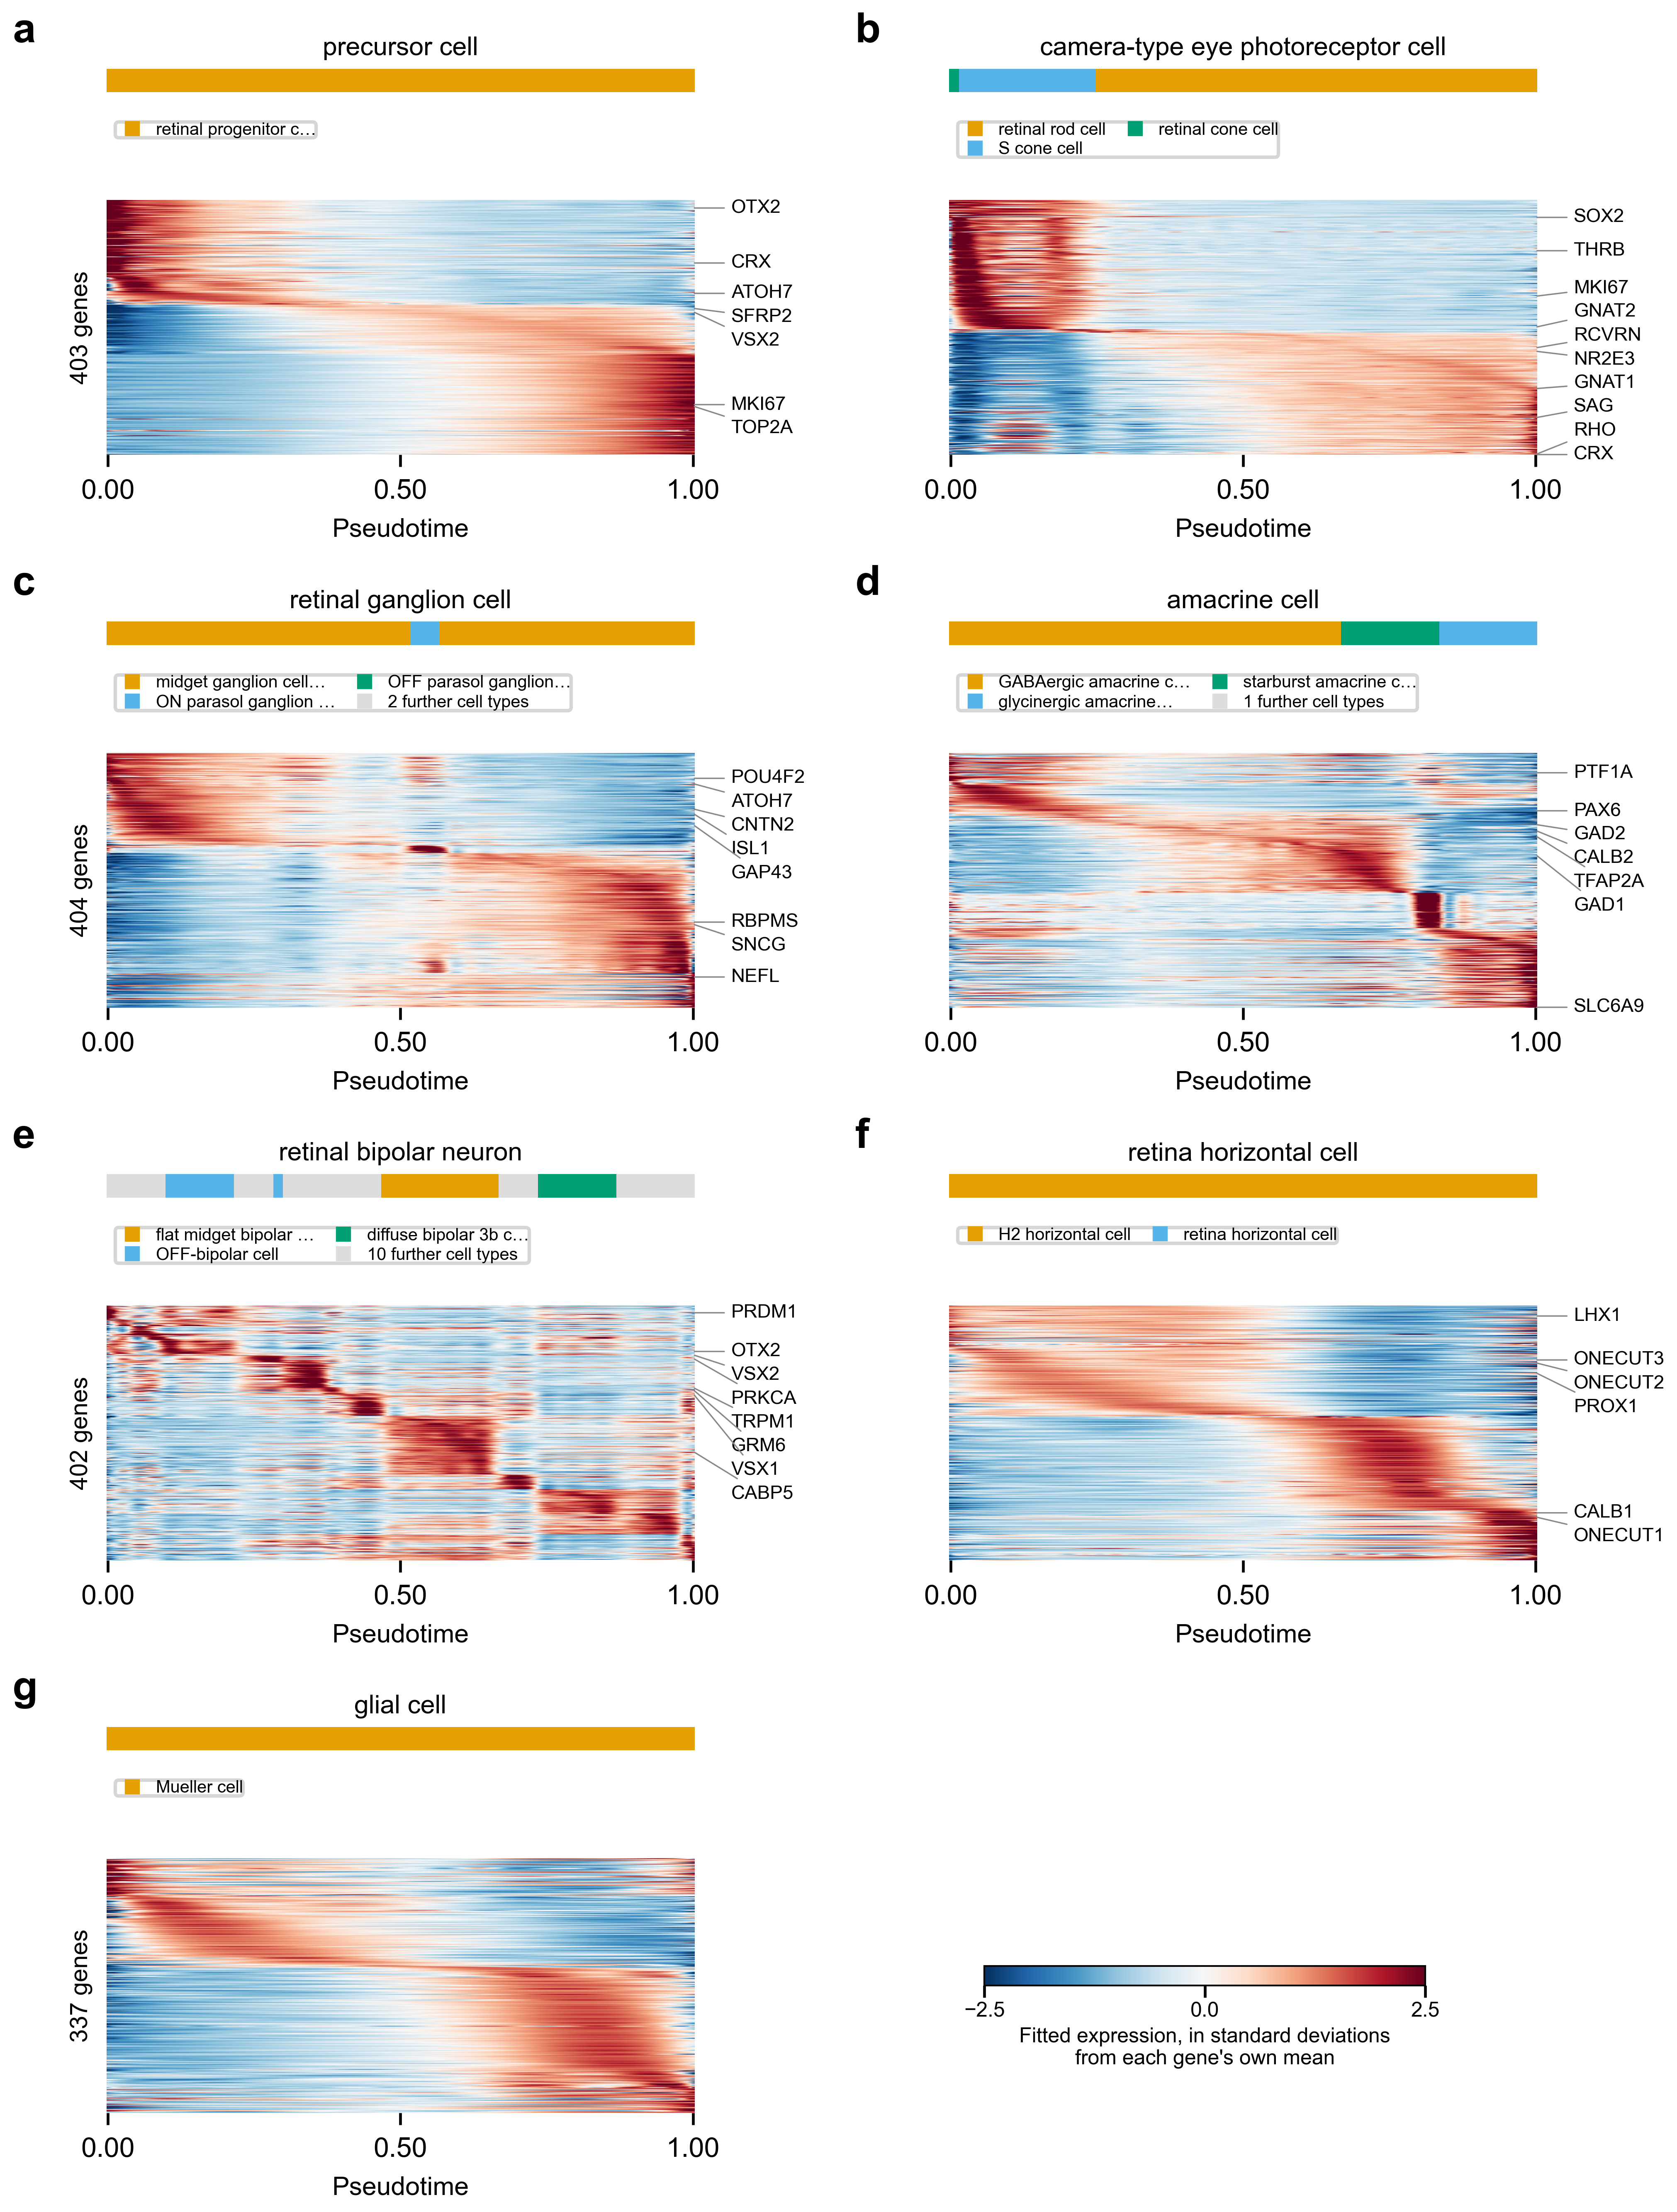

One row per gene, one column per point along the order, colour the fitted
expression in standard deviations from that gene's own mean. Rows are sorted by
`peak_location`, the table's own column, so the picture and the numbers cannot
disagree. Above each map, the cell types occupying that stretch of the order.

`max_genes` is a drawing limit and not a threshold — it takes the strongest 400
per panel, plus anything named in `label_genes` that would otherwise have missed
the cut, which is why the counts beside each map read a little over 400 rather
than exactly 400. Cut the table yourself and pass what you kept if you want
something else.

`width_mm` and `panel_height_mm` set the size. The default is a full page at 180
mm; a single lineage at one and a half columns is:

```python
hector.plot_gene_trends(
    adata, trends[trends["lineage"] == "camera-type eye photoreceptor cell"],
    "07_photoreceptor.pdf", width_mm=120, panel_height_mm=40, panels_per_row=1)
```

A `.pdf` opens in Illustrator with every label a single editable text object and
no clipping masks to release by hand.

## What the answer is worth

**The ordering, more than the list.** Between 337 and 8,018 genes pass in a
lineage here, a share of everything sequenced that ranges from 3% in the
smallest lineage to 40% in the largest. That is partly real —
a lineage running from progenitor to mature cell changes in a great many genes —
and partly that the p-values are anti-conservative: the pseudotime was estimated
from the very cells being tested, so the test does not know how much of the
order it is being handed was itself read off these genes. Every tool in this
family has this problem. Read the sequence, not the length of the list.

**It takes the lineages as given.** If two developmental paths were grouped into
one lineage, the cells are ranked against each other as though they were one
path, and the gene ordering inherits that. Tutorial 06 Step 6 is how you find
and fix it, and it belongs before this step, not after.

**No effect-size filter, deliberately.** It is tempting to keep only genes that
explain some share of their own variation. Do not: at 2% that drops RHO, CRX,
ATOH7 and VSX2. In a developing tissue the decisive genes are the ones only just
switching on, so effect size runs opposite to biological importance.